(5572, 3000)
Training size: (4457, 3000)
Testing size: (1115, 3000)
=== Naive Bayes ===
Accuracy: 0.9713004484304932
              precision    recall  f1-score   support

           0       0.97      1.00      0.98       966
           1       0.99      0.79      0.88       149

    accuracy                           0.97      1115
   macro avg       0.98      0.90      0.93      1115
weighted avg       0.97      0.97      0.97      1115

=== Logistic Regression ===
Accuracy: 0.9614349775784753
              precision    recall  f1-score   support

           0       0.96      1.00      0.98       966
           1       0.99      0.72      0.83       149

    accuracy                           0.96      1115
   macro avg       0.97      0.86      0.91      1115
weighted avg       0.96      0.96      0.96      1115



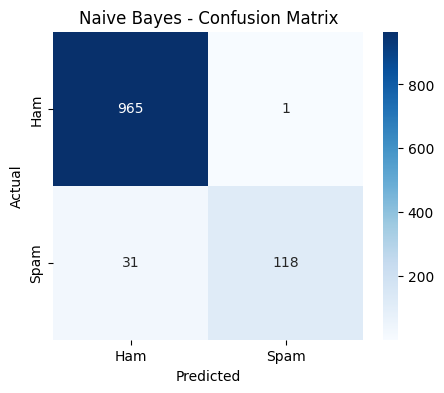

=== False Negatives (missed spam) ===
3057    You are now unsubscribed all services. Get ton...
5       FreeMsg Hey there darling it's been 3 week's n...
855     Talk sexy!! Make new friends or fall in love i...
3139    sexy sexy cum and text me im wet and warm and ...
1662    Hi if ur lookin 4 saucy daytime fun wiv busty ...
3979                                   ringtoneking 84484
3358    Sorry I missed your call let's talk when you h...
5449    Latest News! Police station toilet stolen, cop...
5098    TheMob>Hit the link to get a premium Pink Pant...
3753    Bloomberg -Message center +447797706009 Why wa...
1268    Can U get 2 phone NOW? I wanna chat 2 set up m...
3062    Hi babe its Jordan, how r u? Im home from abro...
1939    More people are dogging in your area now. Call...
1429    For sale - arsenal dartboard. Good condition b...
5110      You have 1 new message. Please call 08715205273
730     Email AlertFrom: Jeri StewartSize: 2KBSubject:...
5492    Marvel Mobile Play the off

In [11]:
import pandas as pd

# Load the dataset
df = pd.read_csv('spam.csv', encoding='latin-1')

# Look at the first few rows
df.head()
# Keep only the useful columns
df = df[['v1', 'v2']]

# Rename them to meaningful names
df.columns = ['label', 'message']

# Confirm it looks right
df.head()
df['label'].value_counts()

import re
import string

# Step 1: Convert labels to numbers
df['label_num'] = df['label'].map({'ham': 0, 'spam': 1})

# Step 2: Text cleaning function
def clean_text(text):
    text = text.lower()                                            # lowercase
    text = re.sub(r'[%s]' % re.escape(string.punctuation), '', text)  # remove punctuation
    text = re.sub(r'\d+', '', text)                                 # remove numbers
    text = re.sub(r'\s+', ' ', text).strip()                        # remove extra spaces
    return text

# Apply cleaning to every message
df['clean_message'] = df['message'].apply(clean_text)

# Check results
df[['message', 'clean_message']].head()


from sklearn.feature_extraction.text import TfidfVectorizer

# Create the vectorizer
tfidf = TfidfVectorizer(max_features=3000, stop_words='english')

# Fit and transform the cleaned text
X = tfidf.fit_transform(df['clean_message'])

# Our labels
y = df['label_num']

print(X.shape)



from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Training size:", X_train.shape)
print("Testing size:", X_test.shape)
from sklearn.naive_bayes import MultinomialNB

nb_model = MultinomialNB()
nb_model.fit(X_train, y_train)

nb_predictions = nb_model.predict(X_test)

from sklearn.linear_model import LogisticRegression

lr_model = LogisticRegression(max_iter=1000)
lr_model.fit(X_train, y_train)

lr_predictions = lr_model.predict(X_test)


from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Naive Bayes results
print("=== Naive Bayes ===")
print("Accuracy:", accuracy_score(y_test, nb_predictions))
print(classification_report(y_test, nb_predictions))

# Logistic Regression results
print("=== Logistic Regression ===")
print("Accuracy:", accuracy_score(y_test, lr_predictions))
print(classification_report(y_test, lr_predictions))

import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(y_test, nb_predictions)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Ham', 'Spam'], yticklabels=['Ham', 'Spam'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Naive Bayes - Confusion Matrix')
plt.show()




# Get the indices of the test set rows
test_indices = y_test.index

# Build a comparison dataframe
results_df = pd.DataFrame({
    'message': df.loc[test_indices, 'message'],
    'actual': y_test.values,
    'predicted': nb_predictions
})

# False Negatives: actual spam, predicted as ham (the 31 we found)
false_negatives = results_df[(results_df['actual'] == 1) & (results_df['predicted'] == 0)]

# False Positives: actual ham, predicted as spam (the 1 we found)
false_positives = results_df[(results_df['actual'] == 0) & (results_df['predicted'] == 1)]

print("=== False Negatives (missed spam) ===")
print(false_negatives['message'].to_string())

print("\n=== False Positives (real email marked spam) ===")
print(false_positives['message'].to_string())


# Custom test messages
custom_messages = [
    "Congratulations! You have WON a free prize, call this number now to claim 09061701461",  # spam
    "Hey Hibba, are we still meeting for the project discussion tomorrow at 5pm?"  # ham
]

# Clean them using the same function from before
custom_clean = [clean_text(msg) for msg in custom_messages]

# Transform using the SAME tfidf vectorizer (don't re-fit, just transform)
custom_vectorized = tfidf.transform(custom_clean)

# Predict using Naive Bayes (our better model)
predictions = nb_model.predict(custom_vectorized)

for msg, pred in zip(custom_messages, predictions):
    label = "SPAM" if pred == 1 else "HAM"
    print(f"Message: {msg}\nPredicted: {label}\n")

    import joblib

joblib.dump(nb_model, 'spam_model.pkl')
joblib.dump(tfidf, 'tfidf_vectorizer.pkl')

print("Saved: spam_model.pkl and tfidf_vectorizer.pkl")